This notebook aims to label cell types using a semi-supervised classification algorithm PhenoGraph. 

By: Britney Tieu Forsyth

In [1]:
# Import packages
from typing import Optional
import phenograph
import scanpy as sc
from anndata import AnnData
from anndata import concat
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib
import os
import pandas as pd
import numpy as np
from scipy.stats import entropy
import subprocess
import palantir
import sys
import random
from collections import OrderedDict
import re
from itertools import chain
import warnings
sys.path.append('/lila/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages')
import harmony
from scipy.sparse import coo_matrix
from sklearn.neighbors import NearestNeighbors
from phenograph.core import find_neighbors, neighbor_graph, jaccard_kernel
%matplotlib inline

findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Lato'] not found. Falling back to DejaVu Sans.


# Dataset Preparation

In [2]:
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/adata.combined.postprocess.h5ad')

In [3]:
adata.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,mito_frac,Patient,Tumor_Site,Culture_Media,ZFP_Expression,Replicate,Batch,Sample,phenograph,leiden
KG146Li_BASE_shCtrl_TGCGGGTTCTCACCCA-1,0.122256,0.999999,9510.026367,0.782633,1127,7.028201,2686,7.896181,49.404319,54.988831,...,0.383098,146,Metastatic,BASE,CTRL,1,2,146_M_BASE_CTRL_1,12,11
KG146Li_HISC_shCtrl_ACTATCTGTAACGGTG-1,0.071823,0.999999,7005.529297,0.771213,1320,7.186144,2528,7.835579,42.761076,47.112342,...,0.362342,146,Metastatic,HISC,CTRL,1,3,146_M_HISC_CTRL_1,19,6
146P_HISC_shZFP36L2_3_TTGTGTTTCCCAAGTA-1,0.031075,0.999950,14507.531250,1.027227,3045,8.021585,9831,9.193398,30.708982,44.634320,...,0.059404,146,Primary,HISC,ZFP_KD,1,6,146_P_HISC_ZFPKD_1,10,13
146Li_dedifferentiation_shCtrl_ATCGATGCACGGAAGT-1,0.033828,0.999974,12912.831055,1.133512,3009,8.009695,8806,9.083302,35.010220,47.172382,...,0.093686,146,Metastatic,Dedifferentiated,CTRL,1,4,146_M_Dediff_CTRL_1,25,29
146P_HISC_shCTRL_GTCGCGACAAGGCTTT-1,0.053984,0.999998,13370.254883,0.725564,2447,7.803027,6547,8.786915,27.157477,39.376814,...,0.042615,146,Primary,HISC,CTRL,1,6,146_P_HISC_CTRL_1,11,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146P_dedifferentiation_shCtrl_CTCCGATTCATTCATC-1,0.097506,0.999994,13538.197266,0.864753,2075,7.638198,4775,8.471359,45.026178,49.759162,...,0.346597,146,Primary,Dedifferentiated,CTRL,1,8,146_P_Dediff_CTRL_1,3,12
KG146Li_BASE_shZFP36L2_4_CTGCTCAAGTAGCAAT-1,0.010058,0.999955,17959.175781,1.036444,4895,8.496174,16396,9.704854,24.646255,33.355697,...,0.094108,146,Metastatic,BASE,ZFP_KD,2,2,146_M_BASE_ZFPKD_2,14,16
KG146Li_HISC_shZFP36L2_4_ATCCCTGCACGCTTAA-1,0.016410,0.999943,8206.400391,1.086645,3007,8.009031,7291,8.894533,26.800165,36.716500,...,0.086957,146,Metastatic,HISC,ZFP_KD,2,3,146_M_HISC_ZFPKD_2,16,18
146Li_dedifferentiation_shCtrl_TACTTGTGTCTTACAG-1,0.017183,0.999955,16893.447266,1.458533,4552,8.423542,11879,9.382612,28.436737,32.452227,...,0.219210,146,Metastatic,Dedifferentiated,CTRL,1,4,146_M_Dediff_CTRL_1,23,36


In [3]:
# Filter rows for primary tumor
primary_tumor = adata[adata.obs.index.str.contains('146P'), :]
primary_tumor

View of AnnData object with n_obs × n_vars = 30354 × 31806
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_p

In [4]:
# Filter rows for metastatic tumor
metastatic_tumor = adata[adata.obs.index.str.contains('KG146Li'), :]
metastatic_tumor

View of AnnData object with n_obs × n_vars = 15981 × 31806
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_p

In [5]:
# Save the filtered data frames to separate files
primary_tumor.write_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/input/degs/primary_tumor.h5ad')
metastatic_tumor.write_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/input/degs/metastatic_tumor.h5ad')

In [14]:
# This is the full patient 146 dataset
adata_patient = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/KG146_Patient_Organoid.h5ad')

In [2]:
# Andrew's patient 146 dataset
adata_patient = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/Tumor_Epithelial_KG146_OKG146Li_Base.h5ad')

In [3]:
adata_patient.obs['Cell State']

120703423826332_OKG146Li_Base         Organoid
120703436384036_OKG146Li_Base         Organoid
120703436605283_OKG146Li_Base         Organoid
120718441539813_OKG146Li_Base         Organoid
120718441801437_OKG146Li_Base         Organoid
                                     ...      
165190304708846_KG146P                     ISC
161384145836979_KG146P                     ISC
200897607945508_KG146P                     ISC
125033721486630_KG146P                     ISC
200444891487139_KG146P           Proliferative
Name: Cell State, Length: 4340, dtype: category
Categories (9, object): ['Absorptive', 'Fetal', 'ISC', 'Injury Repair', ..., 'Organoid', 'Proliferative', 'Secretory', 'Squamous']

In [4]:
adata_patient = adata_patient[~((adata_patient.obs['Cell State'] == 'NA') | (adata_patient.obs['Cell State'] == 'nan') | (adata_patient.obs['Cell State'] == 'Organoid'))]

In [5]:
adata_patient.obs['Cell State'].value_counts()

Cell State
ISC               639
Injury Repair     378
Squamous          279
Proliferative     278
Secretory         239
Absorptive        202
Fetal             107
Neuroendocrine     62
Name: count, dtype: int64

/home/forsythb/.local/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


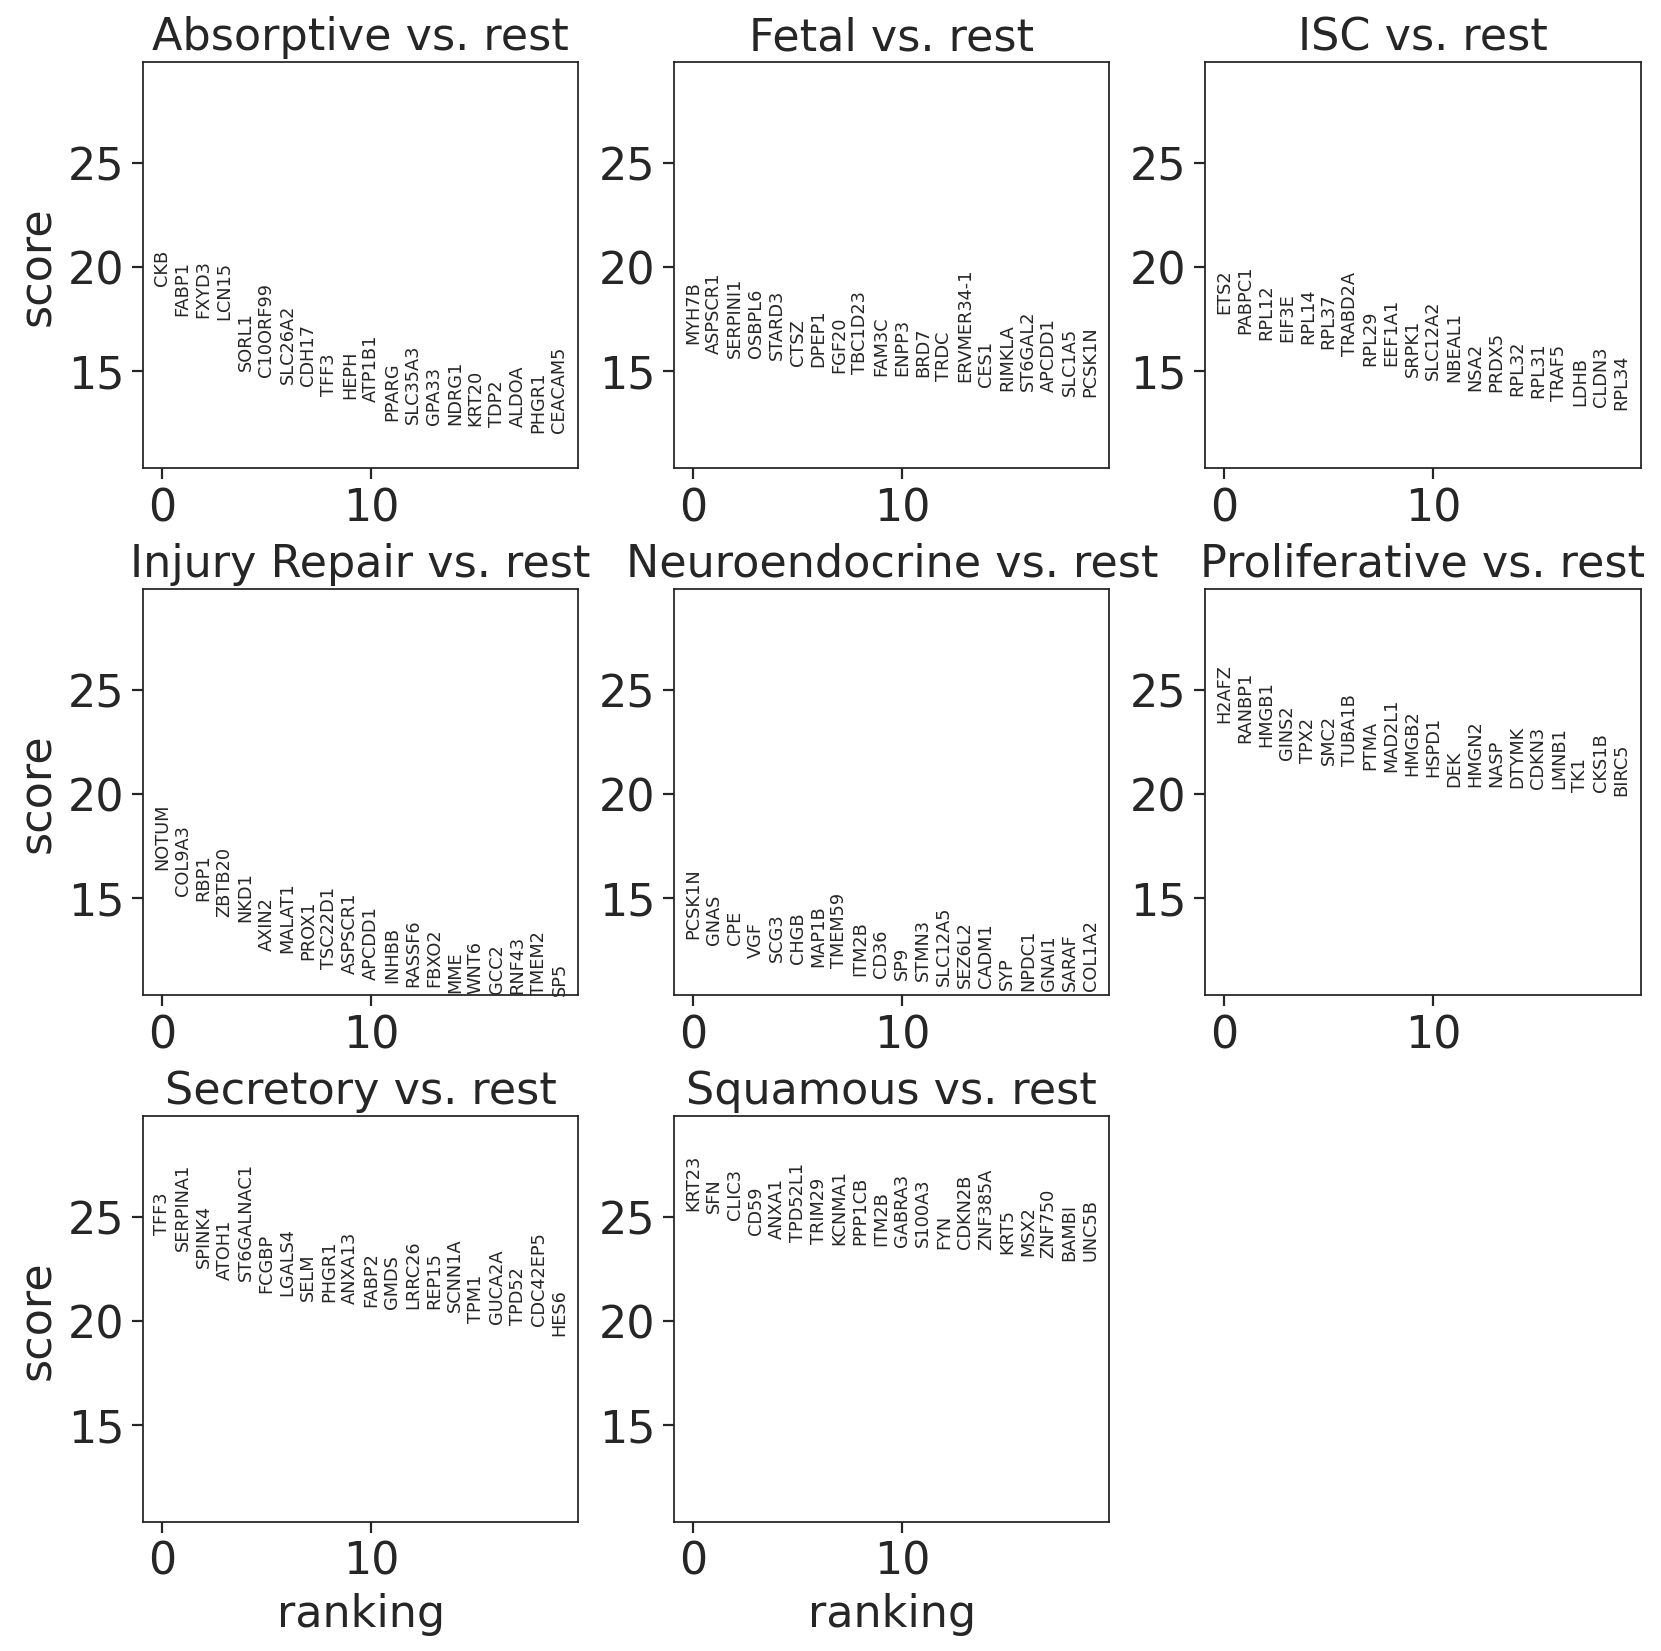

In [58]:
# Perform wilcoxon rank-sum test to idenfity DEGs
sc.tl.rank_genes_groups(adata_patient, groupby='Cell State', method='wilcoxon', key_added='wilcoxon', n_genes=100, use_raw=False)

# Plot the genes
sc.set_figure_params(fontsize=20)
sns.set_style('ticks')
sc.pl.rank_genes_groups(adata_patient, groupby='Cell State', ncols=3)

In [59]:
# Look at the significant DEGs
sig_degs_df = sc.get.rank_genes_groups_df(adata_patient, group=['ISC', 'Injury Repair', 
                                                  'Squamous', 'Proliferative', 
                                                  'Secretory', 'Absorptive', 'Fetal', 
                                                  'Neuroendocrine'], 
                            pval_cutoff=0.001, log2fc_max=3)
sig_degs_df
#sc.get.rank_genes_groups_df(adata_patient, group='Squamous', pval_cutoff=0.001, log2fc_max=3)                         

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,ISC,ETS2,17.754610,1.596823,1.587717e-70,3.200360e-66
1,ISC,PABPC1,16.817003,0.828219,1.831916e-63,1.846296e-59
2,ISC,RPL12,16.530262,0.943978,2.221729e-61,1.492780e-57
3,ISC,EIF3E,16.417900,0.839005,1.424089e-60,7.176341e-57
4,ISC,RPL14,16.330973,0.733045,5.942967e-60,2.395848e-56
...,...,...,...,...,...,...
542,Neuroendocrine,SLC35F5,8.385013,1.778023,5.072032e-17,6.429997e-15
543,Neuroendocrine,NUDT4,8.372958,1.667071,5.618957e-17,6.991440e-15
544,Neuroendocrine,AES,8.361619,1.577924,6.186348e-17,7.650198e-15
545,Neuroendocrine,H3F3B,8.336284,0.877366,7.666172e-17,9.365274e-15


In [69]:
ne_sig_degs_df = sc.get.rank_genes_groups_df(adata_patient, group=['Neuroendocrine'], 
                            pval_cutoff=0.001, log2fc_max>3)
ne_sig_degs_df

SyntaxError: positional argument follows keyword argument (1376235493.py, line 2)

In [67]:
# Look at NE-specific DEGs
ne_sig_degs_df = sc.get.rank_genes_groups_df(adata_patient, group=['Neuroendocrine'], 
                            pval_cutoff=0.001, log2fc_max=3)
ne_sig_degs_df = ne_sig_degs_df['names'].tolist()

ne_gene_markers = ['CHGA', 'CHGB', 'ASCL1', 'NEUROD1', 'INSM1', 'SYP', 'ENO2', 'NCAM1']

genes_present = set(ne_gene_markers) & set(ne_sig_degs_df)

if genes_present:
    print("Genes present in Neuroendocrine gene list:", genes_present)
else:
    print("No common genes found.")

No common genes found.


In [15]:
len(concatenated_data)

600

In [28]:
# These are the identified neuroendocrine DEGs
neuroendocrine_gene_column = deg_dfs['Neuroendocrine']['gene'].tolist()
len(neuroendocrine_gene_column)

100

In [16]:
# See if there is an overlap between identified DEGs and NE gene markers
ne_gene_markers = ['CHGA', 'CHGB', 'ASCL1', 'NEUROD1', 'INSM1', 'SYP', 'ENO2', 'NCAM1']

neuroendocrine_gene_list = deg_dfs['Neuroendocrine']['gene'].tolist()

genes_present = set(ne_gene_markers) & set(neuroendocrine_gene_list)

if genes_present:
    print("Genes present in Neuroendocrine gene list:", genes_present)
else:
    print("No common genes found.")

Genes present in Neuroendocrine gene list: {'SYP', 'CHGB', 'NEUROD1'}


In [14]:
deg_dfs

{'Absorptive':               gene  logfoldchanges         pvals     pvals_adj
 0            LCN15      173.939621  1.160090e-61  2.545817e-57
 1            FABP1      218.036926  3.067347e-60  3.365646e-56
 2              CKB      276.741638  5.530167e-57  4.045317e-53
 3            SORL1        9.411227  4.085953e-45  2.241656e-41
 4            FXYD3       53.685661  7.964266e-40  2.184698e-36
 5          SLC26A2       22.523186  6.759002e-38  1.483263e-34
 6         C10ORF99        7.312545  3.142989e-31  3.448644e-28
 7             HEPH        3.723061  5.849295e-31  5.834672e-28
 8           HAVCR1        4.117408  2.295798e-29  1.865973e-26
 9             TFF3       44.693363  9.741352e-29  7.125799e-26
 10           GPA33        4.086209  6.610397e-28  4.029588e-25
 11           NDRG1       15.422097  2.614848e-27  1.550888e-24
 12           KRT20       13.062303  4.663764e-25  1.895302e-22
 13           MUC20        3.536613  3.704629e-24  1.354968e-21
 14           PPARG       

In [19]:
# Use the significant genes for PCA
significant_genes_pca = concatenated_data['gene'].tolist()

# Subset the original AnnData object to include only significant genes
adata_patient = adata_patient[:, significant_genes_pca]

In [9]:
duplicated_indices = concatenated_data.index[concatenated_data.index.duplicated()]
print("Duplicated indices:", duplicated_indices)

Duplicated indices: Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       ...
       90, 91, 92, 93, 94, 95, 96, 97, 98, 99],
      dtype='int64', length=519)


In [10]:
# Perform wilcoxon rank-sum test to idenfity DEGs
sc.tl.rank_genes_groups(adata_patient, groupby='Cell State', method='wilcoxon', n_genes=100, use_raw=False)
#sc.pl.rank_genes_groups(adata_patient, n_genes=100, sharey=False, key="wilcoxon")

results_dict = adata_patient.uns['wilcoxon']

# Create a dictionary to store dataframes for each group
deg_dfs = {}

# Iterate over each group and create a dataframe
for group in results_dict['names'].dtype.names:
    df = pd.DataFrame(results_dict['names'][group], columns=['gene'])
    df['logfoldchanges'] = results_dict['logfoldchanges'][group]
    df['pvals'] = results_dict['pvals'][group]
    df['pvals_adj'] = results_dict['pvals_adj'][group]
    
    # Filter out highly significant genes
    significant_genes = df[(df['logfoldchanges'].abs() > 3) & (df['pvals_adj'] < 0.001)]
    
    # Store the filtered dataframe in the dictionary
    deg_dfs[group] = significant_genes
    
# Concatenate significant genes from different groups into a single dataframe
concatenated_data = pd.concat([deg_dfs[group] for group in deg_dfs], axis=0)

# Assuming you have already obtained 'aug_mat' and 'aff_mat' from the Harmony and Palantir integration
# Use the significant genes for PCA
significant_genes_pca = concatenated_data['gene'].tolist()

# Subset the original AnnData object to include only significant genes
adata_significant_genes = adata_patient[:, significant_genes_pca]

# Perform PCA on the subsetted data
sc.pp.pca(adata_significant_genes, n_comps=50)

# Perform UMAP on the PCA results
sc.pp.neighbors(adata_significant_genes, n_neighbors=30, metric='cosine')
sc.tl.umap(adata_significant_genes)

# Plot the UMAP
sc.pl.umap(adata_significant_genes, color='Cell State')

# Further downstream analysis or visualization with the subsetted data

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [55]:
# This is the organoid dataset
adata_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/adata.combined.postprocess.h5ad')

In [56]:
# Create a 'Cell State' column where we fill in the values as NA
adata_organoid.obs['Cell State'] = pd.NA

In [57]:
# Subset the organoid data
# Base media, liver metastasis
adata_base_liver = adata_organoid[(adata_organoid.obs['Culture_Media'] == 'BASE') & 
                                  (adata_organoid.obs['Tumor_Site'] == 'Metastatic')]
# Base media, primary 
adata_base_primary = adata_organoid[(adata_organoid.obs['Culture_Media'] == 'BASE') & 
                                  (adata_organoid.obs['Tumor_Site'] == 'Primary')]

# HISC media, liver metastasis
adata_hisc_liver = adata_organoid[(adata_organoid.obs['Culture_Media'] == 'HISC') & 
                                  (adata_organoid.obs['Tumor_Site'] == 'Metastatic')]
# HISC media, primary
adata_hisc_primary = adata_organoid[(adata_organoid.obs['Culture_Media'] == 'HISC') & 
                                  (adata_organoid.obs['Tumor_Site'] == 'Primary')]

# Dedifferentiated media, liver metastasis
adata_dedif_liver = adata_organoid[(adata_organoid.obs['Culture_Media'] == 'Dedifferentiated') & 
                                  (adata_organoid.obs['Tumor_Site'] == 'Metastatic')]
# Dedifferentiated media, primary
adata_dedif_primary = adata_organoid[(adata_organoid.obs['Culture_Media'] == 'Dedifferentiated') & 
                                  (adata_organoid.obs['Tumor_Site'] == 'Primary')]

In [29]:
adata_hisc_primary.var_names

Index(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2ML1-AS1',
       'A2ML1-AS2', 'A3GALT2', 'A4GALT',
       ...
       'ZW10', 'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B',
       'ZYX', 'ZZEF1'],
      dtype='object', name='gene_name', length=31806)

In [26]:
# Use the significant genes for PCA
significant_genes_pca = concatenated_data['gene'].tolist()

# Subset the original AnnData object to include only significant genes
adata_hisc_primary = adata_hisc_primary[:, significant_genes_pca].copy()

KeyError: "Values ['COL1A2', 'KIAA1462', 'KIAA1456', 'FAM105A', 'C10ORF99', 'RP11-357H14.17', 'C2ORF82', 'PCDH18', 'FGF4', 'RP11-234B24.2', 'SELM', 'LINC01207', 'FAM213A', 'YAE1D1', 'RP11-357H14.17', 'RP4-614C10.2', 'AIM1', 'KRT5', 'CALML5', 'FAM84A', 'C15ORF62', 'KIAA0101', 'WHSC1'], from ['PCSK1N', 'CPE', 'SCG3', 'CHGB', 'STMN3', 'VGF', 'CD36', 'COL1A2', 'SP9', 'GNAS', 'KIAA1324', 'MAP1B', 'KIF5C', 'SYP', 'SLC12A5', 'KIAA1462', 'CALB1', 'GNAI1', 'NPDC1', 'KIF1A', 'ADAM23', 'PEG10', 'PODXL2', 'KCNB1', 'TCEAL3', 'TUBB2B', 'SRRM3', 'SMARCA1', 'AMBN', 'RCAN2', 'KREMEN1', 'MSX1', 'DLX5', 'CDK5R2', 'PITPNC1', 'TUBA1A', 'SSTR2', 'SEZ6L2', 'TMX4', 'ITM2B', 'MFAP3L', 'KIAA1456', 'PKIG', 'CADM1', 'SLC4A8', 'NBEA', 'CREB3L1', 'FREM2', 'SEMA6A', 'LAMB1', 'NFASC', 'NRCAM', 'TIMP1', 'EPB41L3', 'MIR7-3HG', 'NEUROD1', 'CNTNAP3B', 'SYT17', 'TMEM59', 'LIX1', 'SLC36A4', 'MT3', 'DLX6', 'CAMK4', 'TGFB2', 'INA', 'MGLL', 'GNG4', 'ENPP2', 'SCG5', 'SDK2', 'CELSR2', 'UTRN', 'FAM105A', 'FGFR1', 'NSMCE3', 'ETV1

In [13]:
adata_dedif_primary.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,Patient,Tumor_Site,Culture_Media,ZFP_Expression,Replicate,Batch,Sample,phenograph,leiden,Cell State
146P_dedifferentiation_shZFP36L2_3_GTTGTAGCACCCTTGT-1,0.101328,0.999998,13794.251953,0.809617,2220,7.705713,5168,8.550435,28.928019,38.448142,...,146,Primary,Dedifferentiated,ZFP_KD,1,8,146_P_Dediff_ZFPKD_1,2,27,NaN
146P_dedifferentiation_shZFP36L2_4_CGGAACCAGATTAGTG-1,0.042722,0.999955,16883.445312,1.118315,3456,8.148156,10142,9.224539,31.068823,39.568133,...,146,Primary,Dedifferentiated,ZFP_KD,2,8,146_P_Dediff_ZFPKD_2,5,14,NaN
146P_dedifferentiation_shZFP36L2_3_AGCGCCATCCTACTGC-1,0.038388,0.999955,16597.630859,1.214109,4336,8.374938,12369,9.423029,26.687687,33.567790,...,146,Primary,Dedifferentiated,ZFP_KD,1,8,146_P_Dediff_ZFPKD_1,2,14,NaN
146P_dedifferentiation_shZFP36L2_4_TGCATCCGTCTACACA-1,0.032979,0.999955,17583.369141,1.278534,4646,8.443977,14539,9.584659,25.744549,34.018846,...,146,Primary,Dedifferentiated,ZFP_KD,2,8,146_P_Dediff_ZFPKD_2,22,25,NaN
146P_dedifferentiation_shCtrl_CAATACGCAGGAGACT-1,0.039262,0.999955,15759.059570,1.332452,4220,8.347827,12606,9.442007,27.129938,35.562431,...,146,Primary,Dedifferentiated,CTRL,1,8,146_P_Dediff_CTRL_1,5,14,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146P_dedifferentiation_shZFP36L2_4_CTTCTAACACTTCATT-1,0.100844,0.999993,11596.277344,1.021119,2446,7.802618,5592,8.629271,38.590844,42.703863,...,146,Primary,Dedifferentiated,ZFP_KD,2,8,146_P_Dediff_ZFPKD_2,28,12,NaN
146P_dedifferentiation_shCtrl_TCTACATAGCTCGTGC-1,0.104757,0.999862,16941.105469,0.769478,1418,7.257708,3106,8.041413,48.197038,52.511269,...,146,Primary,Dedifferentiated,CTRL,1,8,146_P_Dediff_CTRL_1,3,12,NaN
146P_dedifferentiation_shZFP36L2_3_GGCTTGGGTGGCCCAT-1,0.024063,0.999955,16010.648438,1.663486,5176,8.551981,18988,9.851615,23.736044,30.851064,...,146,Primary,Dedifferentiated,ZFP_KD,1,8,146_P_Dediff_ZFPKD_1,2,7,NaN
146P_dedifferentiation_shZFP36L2_4_AACCAACGTAGCCCTG-1,0.024155,0.999955,17665.355469,1.744869,5551,8.621914,20710,9.938420,25.538387,33.384838,...,146,Primary,Dedifferentiated,ZFP_KD,2,8,146_P_Dediff_ZFPKD_2,28,32,NaN


### Base-KG146Li

In [77]:
# Data for liver metastatic cells in base media
adata_patient = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/Tumor_Epithelial_KG146_OKG146Li_Base.h5ad')

In [78]:
# Extract the rows that are not "Organoid"
adata_patient = adata_patient[adata_patient.obs['Cell State'] != 'Organoid', ]

# Extract the rows labeled "KG146M"
adata_patient = adata_patient[adata_patient.obs.index.str.contains('_KG146M'), ]

In [43]:
adata_patient.obs

,n_counts,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,Module Endoderm Development Gene Score,Module Endoderm Development Score,Module Injury Repair Gene Score,Module Injury Repair Score,Module EMT Gene Score,Module EMT Score,Module Neuroendocrine Gene Score,Module Neuroendocrine Score,Media,Patient Tumor
120703424285939_KG146M,12791.0,4122,4122,8.324336,12791.0,9.456575,35.188805,40.575405,47.416152,58.603706,...,-0.144288,0.184177,-0.181300,-0.327645,-0.190323,-0.363053,-0.480979,-1.197567,Patient,Metastasis
120703436155741_KG146M,20657.0,4282,4282,8.362409,20657.0,9.935858,33.862613,42.358523,51.299802,64.660890,...,0.468292,-0.659373,1.274276,7.412497,0.243461,1.022820,0.392913,-1.109128,Patient,Metastasis
120703455025013_KG146M,38341.0,7117,7117,8.870382,38341.0,10.554301,36.214496,42.794919,49.894369,59.197726,...,0.185318,0.183288,-0.120878,0.751803,-0.178741,0.309788,-0.610722,-1.073547,Patient,Metastasis
120718456679846_KG146M,4448.0,1939,1939,7.570443,4448.0,8.400435,27.585432,37.230216,47.819245,64.568345,...,1.014287,2.839662,-0.191981,-1.736034,0.226650,3.434851,0.665020,5.820155,Patient,Metastasis
120718468987109_KG146M,9450.0,2948,2948,7.989221,9450.0,9.153876,37.947090,46.814815,55.544974,67.280423,...,-0.219792,-1.069259,0.038297,-0.127144,0.031821,-0.802285,-0.109984,-1.134468,Patient,Metastasis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241109220584862_KG146M,27669.0,5515,5515,8.615408,27669.0,10.228104,37.413712,43.955329,51.545050,63.016372,...,0.019798,-0.444908,0.420988,3.846963,0.032964,3.365300,0.321801,1.136355,Patient,Metastasis
241176048225691_KG146M,49079.0,5443,5443,8.602269,49079.0,10.801207,36.557387,52.680372,63.043257,73.508018,...,-0.264297,-1.014444,0.004649,-0.880976,0.018582,-0.481893,-0.140216,-1.266137,Patient,Metastasis
241176061270774_KG146M,9075.0,3291,3291,8.099251,9075.0,9.113389,36.396694,42.865014,49.696970,61.123967,...,-0.364293,-0.877892,-0.197890,-1.658545,-0.102189,-0.958512,-0.191856,-1.153119,Patient,Metastasis
241184516782309_KG146M,39697.0,6403,6403,8.764678,39697.0,10.589056,30.644633,38.927375,48.716528,61.107892,...,0.578502,0.371703,-0.078129,0.161784,-0.064378,2.921694,0.460602,1.316424,Patient,Metastasis


In [80]:
# Full dataset for organoid data
adata_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/postprocess_adata.020524/adata.combined.postprocess.h5ad')

In [81]:
# We want the organoid data for Culture Media = BASE and Tumor Site = Metastatic
adata_organoid = adata_organoid[adata_organoid.obs['Culture_Media'] == 'BASE', ]
adata_organoid = adata_organoid[adata_organoid.obs['Tumor_Site'] == 'Metastatic', ]

# Create a 'Cell State' column where we fill in the values as NA
adata_organoid.obs['Cell State'] = pd.NA

/scratch/lsftmp/3277988.tmpdir/ipykernel_100807/1071797391.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_organoid.obs['Cell State'] = pd.NA


In [82]:
adata_organoid

AnnData object with n_obs × n_vars = 7937 × 31596
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden', 'Cell State'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells'
    uns: 'diffmap_evals', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_umap', 'gene_expression_encoding'
    layers: 'without_log'
    obsp: 'connectivities', 'distances'

### Base-KG146P

In [44]:
# Data for primary tumor cells in base media
adata_patient = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/Tumor_Epithelial_KG146_OKG146P_Base.h5ad')

# Extract the rows that are not "Organoid"
adata_patient = adata_patient[adata_patient.obs['Cell State'] != 'Organoid', ]

# Extract the rows labeled "KG146P"
adata_patient = adata_patient[adata_patient.obs.index.str.contains('_KG146P'), ]

In [45]:
# Full dataset for organoid data
adata_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/postprocess_adata.020524/adata.combined.postprocess.h5ad')

# We want the organoid data for Culture Media = BASE and Tumor Site = Primary
adata_organoid = adata_organoid[adata_organoid.obs['Culture_Media'] == 'BASE', ]
adata_organoid = adata_organoid[adata_organoid.obs['Tumor_Site'] == 'Primary', ]

# Create a 'Cell State' column where we fill in the values as NA
adata_organoid.obs['Cell State'] = pd.NA

/scratch/lsftmp/3548328.tmpdir/ipykernel_7432/1880009900.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_organoid.obs['Cell State'] = pd.NA


In [52]:
print(adata_patient.shape)
print(adata_organoid.shape)

(880, 20157)
(50906, 31586)


### hISC-KG146Li

In [2]:
# Data for primary tumor cells in base media
adata_patient = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/Tumor_Epithelial_KG146_OKG146Li_ENAFI.h5ad')

# Extract the rows that are not "Organoid"
adata_patient = adata_patient[adata_patient.obs['Cell State'] != 'Organoid', ]

# Extract the rows labeled "KG146P"
adata_patient = adata_patient[adata_patient.obs.index.str.contains('_KG146M'), ]

In [3]:
# Full dataset for organoid data
adata_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/postprocess_adata.020524/adata.combined.postprocess.h5ad')

# We want the organoid data for Culture Media = hISC and Tumor Site = Metastatic
adata_organoid = adata_organoid[adata_organoid.obs['Culture_Media'] == 'HISC', ]
adata_organoid = adata_organoid[adata_organoid.obs['Tumor_Site'] == 'Metastatic', ]

# Create a 'Cell State' column where we fill in the values as NA
adata_organoid.obs['Cell State'] = pd.NA

/scratch/lsftmp/3277549.tmpdir/ipykernel_13272/3282179677.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_organoid.obs['Cell State'] = pd.NA


In [4]:
print(adata_patient.shape)
print(adata_organoid.shape)

(1304, 20157)
(5756, 31596)


### hISC-KG146P

In [11]:
# Data for primary tumor cells in hisc media
adata_patient = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/Tumor_Epithelial_KG146_OKG146P_ENAFI.h5ad')

# Extract the rows that are not "Organoid"
adata_patient = adata_patient[adata_patient.obs['Cell State'] != 'Organoid', ]

# Extract the rows labeled "KG146P"
adata_patient = adata_patient[adata_patient.obs.index.str.contains('_KG146P'), ]

In [12]:
# Full dataset for organoid data
adata_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/postprocess_adata.020524/adata.combined.postprocess.h5ad')

# We want the organoid data for Culture Media = hISC and Tumor Site = Metastatic
adata_organoid = adata_organoid[adata_organoid.obs['Culture_Media'] == 'HISC', ]
adata_organoid = adata_organoid[adata_organoid.obs['Tumor_Site'] == 'Primary', ]

# Create a 'Cell State' column where we fill in the values as NA
adata_organoid.obs['Cell State'] = pd.NA

/scratch/lsftmp/3548328.tmpdir/ipykernel_7432/2002290597.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_organoid.obs['Cell State'] = pd.NA


In [13]:
print(adata_patient.shape)
print(adata_organoid.shape)

(880, 20157)
(9711, 31596)


### Run pre-processing for all the data

In [32]:
# Ensure both objects have the same set of genes
common_genes = adata_patient.var_names.intersection(adata_hisc_primary.var_names)

# Check for duplicates in common_genes and remove them
#common_genes = common_genes[~common_genes.duplicated()]

# Subset both objects to include only common genes
#adata_patient_common = adata_patient[:, common_genes]
#adata_hisc_primary_common = adata_hisc_primary[:, common_genes].copy()

In [33]:
common_genes

Index(['PCSK1N', 'CPE', 'SCG3', 'CHGB', 'STMN3', 'VGF', 'CD36', 'SP9', 'GNAS',
       'KIAA1324',
       ...
       'DAZAP1', 'TROAP', 'MZT2A', 'GTSE1', 'PBK', 'SNRPD1', 'MIS18BP1',
       'SNRPF', 'BRI3BP', 'CENPH'],
      dtype='object', length=547)

In [30]:
'''
1. Let's concatenate the patient adata and organoid adata based on similar gene names. 
2. Then, create a dataframe to organize the count matrix, cell names, and gene names. 
'''
# Ensure both objects have the same set of genes
common_genes = adata_patient.var_names.intersection(adata_hisc_primary.var_names)

# Subset both objects to include only common genes
adata_patient_common = adata_patient[:, common_genes]
adata_hisc_primary_common = adata_hisc_primary[:, common_genes].copy()

# # Concatenate the data using anndata.concat
# concatenated_data = concat([adata_patient_common, adata_hisc_primary_common])

# # Extract count matrix
# counts_patient_organoid = pd.DataFrame(concatenated_data.X.toarray(),
#                                        index=concatenated_data.obs_names,
#                                        columns=concatenated_data.var_names)

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [ ]:
# Reprocess the data
# 1. Normalization
norm_df = harmony.utils.normalize_counts(counts_patient_organoid)

# Gene selection
hvg_genes = harmony.utils.hvg_genes(norm_df)

# Log transform
data_df = harmony.utils.log_transform(norm_df.loc[:,hvg_genes])

In [207]:
data_df.head()
data_df.tail()

,ROBO2,GPC5,LINC00882,ERBB4,KCNH7,PIK3C2G,PDE1A,DEFA6,LINC00276,SOX5,...,MYOCD,CALCR,LINC00244,WDR90,ZNF565,AKAP6,DCLK2,OPN1SW,LGALS1,AC022182.1
146P_HISC_shCTRL_GCTACAACACGATTCA-1,-3.321928,4.256385,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,...,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928
146P_HISC_shZFP36L2_4_GAGTGTTTCCTGTAAG-1,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,...,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928
146P_HISC_shZFP36L2_4_CCTCCTCCATATGGCT-1,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,...,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928
146P_HISC_shZFP36L2_4_ATGTCTTCAGTCCCGA-1,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,...,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928
146P_HISC_shCTRL_CCTCACAGTTGGTGTT-1,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,...,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928


## Get Affinities

In [171]:
# The patient data is defined as those cells with 'KG146M' in the row name
# Define the time point connections
tp = pd.Series(index=data_df.index)

# Define pattern for Patient cells
patient_pattern = '_KG146'

# Use str.contains to check if the patient pattern is present in the cell identifier
patient_cells = data_df.index[data_df.index.str.contains(patient_pattern)]

# Assign 'Patient' to the corresponding cells in the series
tp[patient_cells] = 'Patient'

# The remaining cells (not classified as Patient) are Organoid cells
tp.fillna('Organoid', inplace=True)

organoid_count = (tp == 'Organoid').sum()
patient_count = (tp == 'Patient').sum()

print(f"Number of Organoid cells: {organoid_count}")
print(f"Number of Patient cells: {patient_count}")

Number of Organoid cells: 9688
Number of Patient cells: 1304


/scratch/lsftmp/3548328.tmpdir/ipykernel_7432/4160515974.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Patient' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tp[patient_cells] = 'Patient'


In [172]:
# Define timepoint connections
timepoint_connections = pd.DataFrame(columns=[0, 1])
index = 0
timepoint_connections.loc[index, :] = ['Organoid', 'Patient']; index += 1
timepoint_connections

,0,1
0,Organoid,Patient


In [173]:
'''
Harmony and Palantir
'''
def _mnn_ka_distances(mnn, n_neighbors):
    # Function to find distance ka^th neighbor in the mutual nearest neighbor matrix
    ka = int(n_neighbors / 3)
    ka_dists = np.repeat(None, mnn.shape[0])
    x, y, z = find(mnn)
    rows=pd.Series(x).value_counts()
    for r in rows.index[rows >= ka]:
        ka_dists[r] = np.sort(z[x==r])[ka - 1]
    return ka_dists

#######################################################################################
from harmony import core
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import find, csr_matrix

def harmony_aug_mat_with_pca(projections, timepoints, timepoint_connections):
    # Time point cells and indices
    tp_cells = pd.Series()
    tp_offset = pd.Series()
    offset = 0
    for i in timepoints.unique():
        tp_offset[i] = offset
        tp_cells[i] = list(timepoints.index[timepoints == i])
        offset += len(tp_cells[i])
    n_neighbors = 30
    
    # Nearest neighbor graph construction and affinity matrix
    print('Nearest neighbor computation...')
    nbrs = NearestNeighbors(n_neighbors=n_neighbors,
                            metric='cosine', n_jobs=-2).fit(projections.values)

    adj = nbrs.kneighbors_graph(projections.values, mode='distance')
    dists, _ = nbrs.kneighbors(projections.values)
    
    # Scaling factors for affinity matrix construction
    ka = int(n_neighbors / 3)
    scaling_factors = pd.Series(dists[:, ka], index=projections.index)
    
    # Affinity matrix
    nn_aff = core._convert_to_affinity(adj, scaling_factors, True)
    n_jobs = -2
    
    # Mututally nearest neighbor affinity matrix
    # Initilze mnn affinity matrix
    N = projections.shape[0]
    full_mnn_aff = csr_matrix(([0], ([0], [0])), [N, N])
    for i in timepoint_connections.index:
        t1, t2 = timepoint_connections.loc[i, :].values
        print(f'Constucting affinities between {t1} and {t2}...')
        # MNN matrix  and distance to ka the distance
        t1_cells = tp_cells[t1]
        t2_cells = tp_cells[t2]
        mnn = core._construct_mnn(t1_cells, t2_cells, projections,
                             n_neighbors, n_jobs)
        
        # MNN Scaling factors
        # Distance to the adaptive neighbor
        ka_dists = pd.Series(0.0, index=t1_cells + t2_cells)
        ka_dists = ka_dists.astype(float)
        # T1 scaling factors
        ka_dists[t1_cells] = _mnn_ka_distances(mnn, n_neighbors)
        # T2 scaling factors
        ka_dists[t2_cells] = _mnn_ka_distances(mnn.T, n_neighbors)
        # Scaling factors
        mnn_scaling_factors = pd.Series(0.0, index=projections.index)
        mnn_scaling_factors[t1_cells] = core._mnn_scaling_factors(
            ka_dists[t1_cells], scaling_factors)
        mnn_scaling_factors[t2_cells] = core._mnn_scaling_factors(
            ka_dists[t2_cells], scaling_factors)
        # MNN affinity matrix
        full_mnn_aff = full_mnn_aff + \
            core._mnn_affinity(mnn, mnn_scaling_factors,
                          tp_offset[t1], tp_offset[t2])
    # Symmetrize the affinity matrix and return
    aug_aff2 = nn_aff + nn_aff.T + full_mnn_aff + full_mnn_aff.T
    aff2 = nn_aff + nn_aff.T
    return aug_aff2, aff2

In [174]:
pca_merge = pd.DataFrame(concatenated_data.obsm['X_pca'], index=concatenated_data.obs_names)
aug_mat, aff_mat = harmony_aug_mat_with_pca(pca_merge, tp, timepoint_connections)

Nearest neighbor computation...
Constucting affinities between Organoid and Patient...
t+1 neighbors of t...
t neighbors of t+1...


/scratch/lsftmp/3548328.tmpdir/ipykernel_7432/3931875684.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[None None None ... None 17.74883403528355 None]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ka_dists[t1_cells] = _mnn_ka_distances(mnn, n_neighbors)


In [175]:
# Save the combined adata object
#combined_adata.write_h5ad(os.path.join(out_dir, 'combined_adata.h5'))
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/harmony_phenograph.020724/'
os.makedirs(out_dir,exist_ok=True)

In [176]:
# Convert arrays to string format
# Convert non-string columns in the "obs" DataFrame to strings
concatenated_data.obs = concatenated_data.obs.applymap(str)

# Add aug_mat to adata_patient_organoid
concatenated_data.obsm['aug_mat'] = aug_mat.toarray()

# Add aff_mat to adata_patient_organoid
concatenated_data.obsm['aff_mat'] = aff_mat.toarray()

# Save the modified patient 146 organoid adata 
concatenated_data.write('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/harmony_phenograph.020724/adata_harmony_hisc_primary.h5ad')

/scratch/lsftmp/3548328.tmpdir/ipykernel_7432/2265753106.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  concatenated_data.obs = concatenated_data.obs.applymap(str)


## PhenoGraph Classification

In [177]:
adata_patient_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/harmony_phenograph.020724/adata_harmony_hisc_primary.h5ad')

In [178]:
aug_mat = pd.DataFrame(adata_patient_organoid.obsm['aug_mat'], index=adata_patient_organoid.obs.index, columns = adata_patient_organoid.obs.index)

In [179]:
adata_patient_organoid.obs['Cell State'] = adata_patient_organoid.obs['Cell State'].astype(str).fillna('NaN')

In [180]:
ind = adata_patient_organoid.obs['Cell State'] != 'NaN'
adata_patient_organoid = adata_patient_organoid[ind, :]
aug_mat = aug_mat.loc[ind, ind]

In [181]:
# Select cells with labeled cell state (excluding 'NA')
ind = adata_patient_organoid.obs['Cell State'] != 'nan'
labeled_cells = adata_patient_organoid[ind,:]

# Get unique cell types/categories
cell_types = labeled_cells.obs['Cell State'].unique()

# Initialize an empty list to store training data for each cell type
train_data = []
train_labels = []
ct_codes = []

# Iterate over cell types and extract 'aug_mat' for each
for i,cell_type in enumerate(cell_types):
    # Filter cells of the current cell type
    cells_of_type = labeled_cells[labeled_cells.obs['Cell State'] == cell_type]
    
    # Extract 'aug_mat' for these cells
    pc_data = cells_of_type.obsm['X_pca']  # Assuming sparse matrix to array
    
    # Append 'aug_mat' data to the list
    train_data.append(pc_data)
    train_labels.append(cells_of_type.obs.index.to_series())   
    ct_codes += [i+1]*pc_data.shape[0]

In [182]:
train_labels = pd.concat(train_labels).index

In [183]:
# # Select cells with labeled cell state (excluding 'nan') for test data
test_cells = adata_patient_organoid[adata_patient_organoid.obs['Cell State'] == 'nan']
#adata_patient_organoid.obs['Cell State'] = adata_patient_organoid.obs['Cell State'].replace('NaN', np.nan)
#test_cells = adata_patient_organoid[adata_patient_organoid.obs['Cell State'].isna()]

# # Extract 'aug_mat' for test cells
test_data = test_cells.obsm['X_pca']
test_labels = test_cells.obs.index

In [184]:
labels = pd.Index(test_labels.tolist() +  train_labels.tolist())

In [185]:
aug_all = coo_matrix(aug_mat.loc[labels,labels].values )

In [186]:
ct_codes = np.array([0]*len(test_labels) + ct_codes)

In [187]:
def preprocess(train, test):
    labels = np.zeros((test.shape[0], ), dtype=int)
    data = test
    for c, examples in enumerate(train):
        labels = np.append(labels, np.tile(c+1, (examples.shape[0], )), axis=0)
        data = np.append(data, examples, axis=0)
    # Check that results are valid
    if labels[-1] == 0:
        raise IndexError("Last entry in labels should not be 0")
    if labels.shape[0] != data.shape[0]:
        raise IndexError("Data and labels should be the same length")
    if sum(labels == 0) != test.shape[0]:
        raise IndexError("Labels should include one 0 for every row of test data")
    return data, labels

In [188]:
data, labels = preprocess(train_data, test_data)

In [189]:
def create_graph(data, k=30, metric='euclidean', n_jobs=-1):
    # def _kernel(dxy, sigma=1):
    #     return np.exp(-dxy ** 2 / sigma)

    _, idx = find_neighbors(data, k=k, metric=metric, n_jobs=n_jobs)
    # affinities = np.apply_along_axis(lambda x: _kernel(x, x.std()), axis=1, arr=d)
    # n, k = idx.shape
    # i = [np.tile(x, (k, )) for x in range(n)]
    # i = np.concatenate(np.array(i))
    # j = np.concatenate(idx)
    # s = np.concatenate(affinities)
    # graph = sp.coo_matrix((s, (i, j)), shape=(n, n)).tocsr()
    # graph = (graph + graph.transpose()).multiply(.5)
    graph = neighbor_graph(jaccard_kernel, {'idx': idx})
    # make symmetric
    # graph = (graph + graph.transpose()).multiply(.5)
    return graph

In [190]:
# Assuming aug_all is your coo_matrix
subset_rows = slice(0, 50)
subset_cols = slice(0, 10)
subset_aug_all = aug_all.tocsr()[subset_rows, subset_cols]

# Now pass the subset to the create_graph function
# create_graph(subset_aug_all)

# dense_subset_aug_all = subset_aug_all.toarray()
# create_graph(dense_subset_aug_all)

In [191]:
dense_subset_aug_all = subset_aug_all.toarray()
create_graph(dense_subset_aug_all)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm


<50x50 sparse matrix of type '<class 'numpy.float64'>'
	with 1500 stored elements in COOrdinate format>

In [192]:
import numpy as np
from phenograph.core import find_neighbors, neighbor_graph, jaccard_kernel
import scipy.sparse as sp
from sklearn.preprocessing import normalize


def random_walk_probabilities(A, labels):

    if labels.min() != 0:
        raise ValueError("Labels should encode unlabeled points with 0s")

    # Check if input is sparse
    if sp.issparse(A):
        if not isinstance(A, sp.csr_matrix):
            A = A.tocsr()
        D = sp.diags(A.sum(axis=1).flatten(), [0], shape=A.shape, format='csr')
        L = D - A
        seeds = labels != 0
        Lu = L[np.invert(seeds), :]  # unlabeled rows
        Lu = Lu.tocsc()[:, np.invert(seeds)]  # unlabeled columns
        # Check that Lu has the right size
        if not all([t == sum(np.invert(seeds)) for t in Lu.shape]):
            raise IndexError("Lu should be square and match size of test data")
        BT = L[np.invert(seeds), :]  # unlabeled rows
        BT = BT.tocsc()[:, seeds]  # labeled columns
        if not (sum(np.invert(seeds)), sum(seeds)) == BT.shape:
            raise IndexError("BT size is incorrect")
        # Matrix representation of labels
        i, j, s = [], [], []
        classes = np.unique(labels[seeds.nonzero()[0]])
        for k in classes:
            i.extend(np.where(labels[seeds] == k)[0])
            j.extend(np.tile(k, sum(seeds == k)))
            s.extend(np.tile(1, sum(seeds == k)))
        i = np.arange(seeds.sum())
        j = labels[seeds] - 1
        s = np.ones((seeds.sum(), ))
        M = sp.coo_matrix((s, (i, j)), shape=(seeds.sum(), len(classes))).tocsc()
        # P = sp.linalg.spsolve(Lu.tocsc(), -BT.dot(M))
        # Use iterative solver
        B = -BT.dot(M)
        vals = [sp.linalg.isolve.bicgstab(Lu, b.T.todense()) for b in B.T]
        warnings = [x[1] for x in vals]
        if any(warnings):
            print("Warning: iterative solver failed to converge in at least one case", flush=True)
        P = normalize(np.vstack(tuple((x[0] for x in vals))).T, norm='l1')

    else:
        D = np.diag(np.sum(A, axis=1))
        L = D - A  # graph laplacian
        seeds = np.array([e != 0 for e in labels], dtype=bool)
        Lu = L[seeds, :][:, seeds]  # labeled rows, labeled cols
        BT = L[~seeds, :][:, seeds]  # unlabeled rows, labeled cols
        classes = np.unique(labels[labels > 0])
        M = np.zeros((seeds.sum(), len(classes)))
        for k in classes:
            M[labels[seeds] == k, k] = 1
        P = np.linalg.lstsq(Lu, np.dot(-BT, M))[0]

    return P

In [193]:
P = random_walk_probabilities(aug_all, ct_codes)

/scratch/lsftmp/3548328.tmpdir/ipykernel_7432/3655095487.py:42: DeprecationWarning: Please use `bicgstab` from the `scipy.sparse.linalg` namespace, the `scipy.sparse.linalg.isolve` namespace is deprecated.
  vals = [sp.linalg.isolve.bicgstab(Lu, b.T.todense()) for b in B.T]


In [194]:
pval_df = pd.DataFrame(P, index = test_cells.obs_names, columns = cell_types)

In [195]:
pval_df.to_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/harmony_phenograph.020724/adata_phenograph_hisc_primary.csv', index=True)

In [196]:
pval_df

,ISC-like,SCC,Fetal Progenitor,Enterocyte-like,TA-like,Injury Repair,Early NET,Goblet-like
146P_HISC_shZFP36L2_4_GTGCAGCAGAGAGGGC-1,0.256830,0.075374,0.048427,0.154813,0.157126,0.252274,0.016754,0.038403
146P_HISC_shCTRL_TGCAGATAGTCTACCA-1,0.141261,0.017753,0.010613,0.499473,0.034929,0.108700,0.006471,0.180799
146P_HISC_shCTRL_AAGAACAAGGACACTG-1,0.171064,0.019938,0.011903,0.438628,0.038472,0.108529,0.007090,0.204376
146P_HISC_shCTRL_GAATAGACAGGGATAC-1,0.195064,0.048162,0.029093,0.233121,0.183593,0.197025,0.020580,0.093361
146P_HISC_shZFP36L2_4_ACATCCCTCGCCACTT-1,0.317866,0.056968,0.042492,0.225330,0.060235,0.263923,0.010282,0.022904
...,...,...,...,...,...,...,...,...
146P_HISC_shCTRL_GCTACAACACGATTCA-1,0.168538,0.019893,0.011448,0.471683,0.041456,0.106862,0.007145,0.172975
146P_HISC_shZFP36L2_4_GAGTGTTTCCTGTAAG-1,0.349714,0.051726,0.038117,0.249109,0.063265,0.213838,0.010127,0.024105
146P_HISC_shZFP36L2_4_CCTCCTCCATATGGCT-1,0.221319,0.088568,0.060674,0.138356,0.164633,0.265061,0.019535,0.041853
146P_HISC_shZFP36L2_4_ATGTCTTCAGTCCCGA-1,0.435071,0.042060,0.032066,0.221536,0.055520,0.185873,0.008466,0.019407
